# Deep Learning - Exercise 4

This lecture is about advanced topics of the CNN such as transfer learning and 1D convolutions for time-series processing.

We will use CIFAR-10 dataset again and [FordA](https://www.timeseriesclassification.com/description.php?Dataset=FordA) for time-series classification task.

**Core Concepts**
* 🧠 Transfer learning techniques in CNNs
* 📈 1D Convolutions for time-series processing
* 📊 CIFAR-10 dataset utilization
* ⏱️ FordA dataset for time-series classification tasks

[Open in Google colab](https://colab.research.google.com/github/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/dl_04.ipynb)
[Download from Github](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/dl_04.ipynb)

##### Remember to set **GPU** runtime in Colab!

In [ ]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import pandas as pd
import matplotlib.pyplot as plt # plotting
import matplotlib.image as mpimg # images
import seaborn as sns # plotting
import numpy as np #numpy
import tensorflow as tf
import tensorflow.keras as keras
import requests

from tensorflow.keras.layers import Activation
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import VGG19

from sklearn.model_selection import train_test_split # split for validation sets
from sklearn.preprocessing import normalize # normalization of the matrix
from scipy.signal import convolve2d # convolutionof the 2D signals
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from PIL import Image
from io import BytesIO
from skimage.transform import resize


tf.version.VERSION

'2.19.0'

In [ ]:
def show_history(history):
    plt.figure()
    for key in history.history.keys():
        plt.plot(history.epoch, history.history[key], label=key)
    plt.legend()
    plt.tight_layout()

def show_example(train_x, train_y, class_names):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(train_x[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[train_y[i][0]])
    plt.show()

def compute_metrics(y_true, y_pred, show_confusion_matrix=False):
    print(f'\tAccuracy: {accuracy_score(y_true, y_pred)*100:8.2f}%')
    if (show_confusion_matrix):
        print('\tConfusion matrix:\n', confusion_matrix(y_true, y_pred))

# 🔎 What is *transfer learning* about? 🔎

* Transfer learning consists of taking features learned on one problem, and leveraging them on a new, similar problem.
    * For instance, features from a model that has learned to identify cars may be useful to kick-start a model meant to identify trucks.
        * 🔎 Do you know any famous CNN models?

* Transfer learning is usually done for tasks where your dataset has too little data to train a full-scale model from scratch.
    * 🔎 How do we benefit from it?
    
## 📌 Usual pipeline

1) Take layers from a previously trained model.

2) Freeze them, so you avoid destroying any of the information they contain during future training rounds.

3) Add some new, trainable layers, on top of the frozen layers.
    * 💡 They will learn how to turn the features extracted by pre-trained layers into predictions on a new dataset.

4) Train the new layers using your dataset.

* 💡 Optional step: Fine-tuning (= unfreezing the entire model you obtained above, or part of it), and re-training it on the new data with a very **low** learning rate.
    * This can potentially achieve meaningful improvements, by incrementally adapting the pretrained features to the new data.
    * 🔎 Why do we use **low** learning rate?


# 🚀 Let's start!

## Import dataset **CIFAR10** again
* I think (or hope 😀) that you remember most of these detailes from the previous lecture 🙂
    * The CIFAR-10 dataset contains 60,000 32x32 color images in 10 different classes.
    * The 10 different classes represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks.
    * There are 6,000 images of each class.

## We will resize the images into (224, 224) shape because we will use ResNet50 later and we will also one-hot encode our labels
* 💡 If you do not encode the labels you will run into shape mismatch error which is hard to debug - trust me, I've been there 🙂

In [ ]:
# cifar is the basic dataset for image classifaction
dataset = tf.keras.datasets.cifar10
img_size = 224
subset = 1000
test_size = 0.2

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
class_count = len(class_names)

# data from any dataset are loaded using the load_Data function
(train_x, train_y), (test_x, test_y) = dataset.load_data()

train_y = tf.keras.utils.to_categorical(train_y[:subset], class_count)
test_y = tf.keras.utils.to_categorical(test_y[:subset], class_count)

train_x_resized = tf.image.resize(train_x[:subset], [img_size, img_size], )
test_x_resized = tf.image.resize(test_x[:subset], [img_size, img_size])

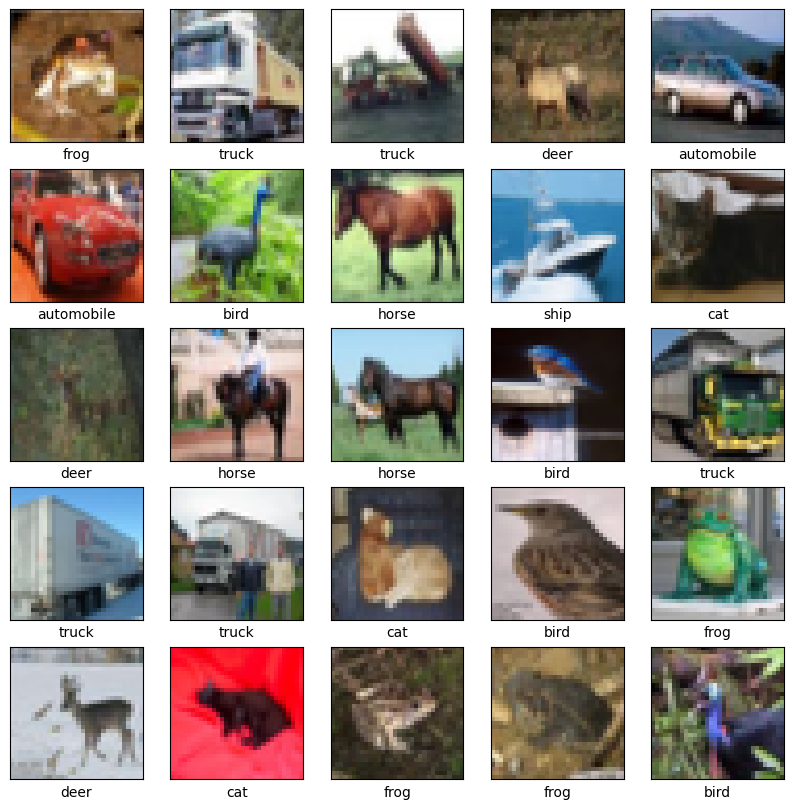

In [ ]:
show_example(train_x, np.argmax(train_y, axis=1).reshape(-1, 1), class_names)

# Instantiate a `ResNet50` model with pre-trained weights.
* 🔎 What the **include_top** do?
* What means **weights='imagenet'** parameter?
    * 🔎 Do we need it?
    * 🔎 What happens if we use random weights?

In [ ]:
base_model = ResNet50(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(img_size, img_size, 3),
    include_top=False)  # Do not include the ImageNet classifier part at the top.

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


## 📌 IMPORTANT: Freeze the base model 📌
* We don't want to train the encoder path of model yet

In [ ]:
base_model.trainable = False

# ⚡ Create a model input and output layers and interconnect all the parts together
* 💡 We make sure that the base_model is running in inference mode here, by passing `training=False`.

## 📌 Notes about BatchNormalization layer
* Many image models contain **BatchNormalization** layers.
* Here are a few things to keep in mind:
    * BatchNormalization contains 2 non-trainable weights that get updated during training.
        * These are the variables **tracking the mean and variance of the inputs**.
* 💡 When you **unfreeze** a model that contains BatchNormalization layers in order to do **fine-tuning**, you should **keep the BatchNormalization layers in inference mode by passing training=False** when calling the base model.
    * **Otherwise the updates applied to the non-trainable weights will suddenly destroy what the model has learned.**


* 🔎 What the **GlobalAveragePooling2D** layer does?
    * After convolutional operations, *tf.keras.layers.Flatten* will reshape a tensor into (n_samples, height*width*channels), for example turning (16, 28, 28, 3) into (16, 2352)
    * *GlobalAveragePooling* layer is an alternative to this because it averages all the values according to the last axis.
        * This means that the resulting shape will be (n_samples, last_axis).
        * 💡 For instance, if your last convolutional layer had 64 filters, it would turn (16, 7, 7, 64) into (16, 64)

# 📌 Make sure that you call the `preprocess_input` function
* Each Keras Application expects a specific kind of input preprocessing.
* For ResNet, call `tf.keras.applications.resnet.preprocess_input` on your inputs before passing them to the model.
    * 💡 It will convert the input images from RGB to BGR, then will zero-center each color channel with respect to the ImageNet dataset, without scaling.

In [ ]:
inputs = keras.Input(shape=(img_size, img_size, 3), dtype=tf.uint8)
x = keras.ops.cast(inputs, dtype=tf.float32)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(class_count, activation='softmax')(x)
model = keras.Model(inputs, outputs)

## Compile the model and check number of parameters
* Why do we have only **20,490** trainable parameters?
* Why do we use `CategoricalAccuracy` and `CategoricalCrossentropy`?

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy()])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ cast[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ cast[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │     20,490 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

![Meme01](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_meme_tf_01.png?raw=true)

## 💡 Always check if all the shapes match the pre-defined ranges!
* Otherwise you will run into shape missmatch issue in the training loop and it is harder to debug than the C++ templates 😅

In [ ]:
train_x_resized.shape, train_y.shape

(TensorShape([1000, 224, 224, 3]), (1000, 10))

In [ ]:
test_x_resized.shape, test_y.shape

(TensorShape([1000, 224, 224, 3]), (1000, 10))

## 🚀 Fit the model

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 422ms/step - categorical_accuracy: 0.3913 - loss: 1.8107 - val_categorical_accuracy: 0.6900 - val_loss: 0.9223
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - categorical_accuracy: 0.7937 - loss: 0.6563 - val_categorical_accuracy: 0.8000 - val_loss: 0.6268
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - categorical_accuracy: 0.8775 - loss: 0.4217 - val_categorical_accuracy: 0.8100 - val_loss: 0.5509
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - categorical_accuracy: 0.9150 - loss: 0.3133 - val_categorical_accuracy: 0.8300 - val_loss: 0.4724
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - categorical_accuracy: 0.9538 - loss: 0.2267 - val_categorical_accuracy: 0.8450 - val_loss: 0.4279
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - categorical_accuracy: 0.9725 - loss: 0.1779 - val_categorical_accuracy: 0.8600 - val_loss: 0.4136
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - categorical_accuracy: 0.9850 - lo

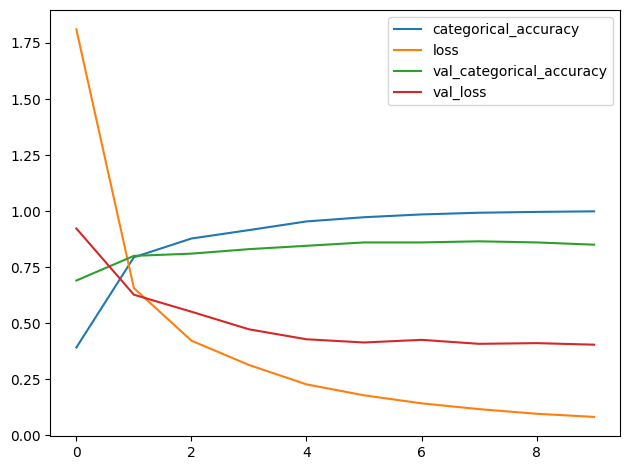

In [ ]:
history = model.fit(train_x_resized, train_y, validation_split=0.2, batch_size=32, epochs=10, callbacks=[model_checkpoint_callback])

show_history(history)

# Load best setup
model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x_resized, test_y)
print('Test accuracy: ', test_acc)

# 🚀 Fine-tuning
* Once your model has converged on the new data, you can try to unfreeze all or part of the base model and retrain the whole model end-to-end with a very low learning rate.
    * 💡 It could also potentially lead to quick overfitting -- keep that in mind.
* It is critical to only do this step **after the model with frozen layers has been trained to convergence**.
    * 💡 If you mix randomly-initialized trainable layers with trainable layers that hold pre-trained features the randomly-initialized layers will cause very large gradient updates during training,
    * This will **destroy your pre-trained features**.
    
### It's also critical to use a *very low learning rate* at this stage,
* You are training a much larger model than in the first round of training, on a dataset that is typically very small.
    * 💡 As a result, you are at **risk of overfitting** very quickly if you apply large weight updates.

## Unfreeze the base model

In [ ]:
base_model.trainable = True

## 💡 Recompile your model after you make any changes
* The `trainable` attribute of any inner layer is taken into account after re-compilation

* Calling `compile()` on a model is meant to "freeze" the behavior of that model.
    * This implies that the trainable attribute values at the time the model is compiled should be preserved throughout the lifetime of that model, until compile is called again.
    * Hence, if you change any trainable value, make sure to call `compile()` again on your model for your changes to be taken into account.

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy()])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ cast[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ cast[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │     20,490 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 23,555,082 (89.86 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 73s 663ms/step - categorical_accuracy: 0.6700 - loss: 0.9434 - val_categorical_accuracy: 0.8100 - val_loss: 0.4837
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/step - categorical_accuracy: 0.9000 - loss: 0.3791 - val_categorical_accuracy: 0.8000 - val_loss: 0.5765
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 328ms/step - categorical_accuracy: 0.9725 - loss: 0.1867 - val_categorical_accuracy: 0.7950 - val_loss: 0.5877
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 334ms/step - categorical_accuracy: 0.9950 - loss: 0.1271 - val_categorical_accuracy: 0.7900 - val_loss: 0.5653
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 346ms/step - categorical_accuracy: 1.0000 - loss: 0.0750 - val_categorical_accuracy: 0.7950 - val_loss: 0.5662
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 353ms/step - categorical_accuracy: 0.9962 - loss: 0.0620 - val_categorical_accuracy: 0.7850 - val_loss: 0.5654
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 366ms/step - categorical_accuracy: 1.0000 - lo

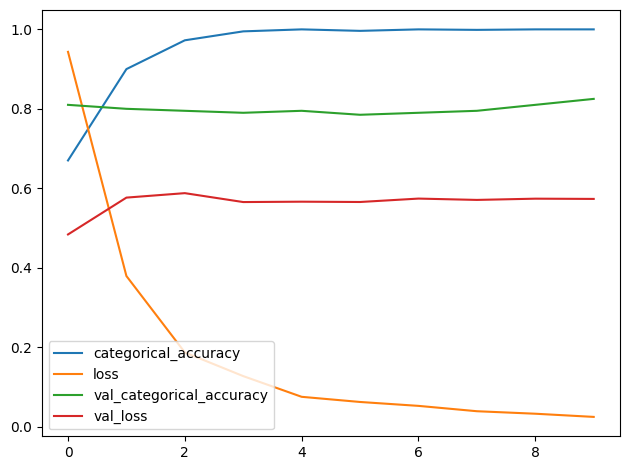

In [ ]:
history = model.fit(train_x_resized, train_y, validation_split=0.2, batch_size=32, epochs=10, callbacks=[model_checkpoint_callback])

show_history(history)

In [ ]:
# Load best setup
model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x_resized, test_y)
print('Test accuracy: ', test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - categorical_accuracy: 0.8200 - loss: 0.5220
Test accuracy:  0.8199999928474426


## Now you are an absolute expert in CNN applications in the image classification tasks 👏

## We can switch to time series processing part of the lecture! 🙂
* 🔎What tasks can you imagine for time series processing?
* We will use CNN again, but now in Conv1D variant
    * 🔎 What is the difference among the 1 - 3D Conv?

### There is definitely a cool mathematical expression for each conv layer type however I would like you to understand the topic so we will use the diagrams below 🙂

![Meme02](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_meme_tf_02.png?raw=true)

### 📒 Conv2D
* Conv2D is generally used on Image data.
* It is called 2 dimensional CNN because the kernel slides along 2 dimensions on the data as shown in the following image.

![Conv2D](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_04_conv2d.png?raw=true)


### 📒 Conv1D
* Following plot illustrate how the kernel will move on accelerometer data.
* Each row represents time series acceleration for some axis.
    * The kernel can only move in one dimension along the axis of time.

![Conv1D](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_04_conv1d.png?raw=true)

# 📌 Summary
* In 1D CNN, kernel moves in 1 direction. Input and output data of 1D CNN is 2 dimensional. Mostly used on Time-Series data.
* In 2D CNN, kernel moves in 2 directions. Input and output data of 2D CNN is 3 dimensional. Mostly used on Image data.
* In 3D CNN, kernel moves in 3 directions. Input and output data of 3D CNN is 4 dimensional. Mostly used on 3D Image data (MRI, Video).
    * 💡 You can check https://towardsdatascience.com/understanding-1d-and-3d-convolution-neural-network-keras-9d8f76e29610 for more details

# Download the FordA data

* Let's download [FordA](https://www.timeseriesclassification.com/description.php?Dataset=FordA) dataset converted for our purposes to the [Feather file format](https://arrow.apache.org/docs/python/feather.html), a binary file format for data exchange.

* 💡 The classification problem is to diagnose whether a certain symptom exists or does not exist in an automotive subsystem.
    * Each case consists of 500 measurements of engine noise and a classification.

* 💡 The data originates from ARFF file format used in Weka Data analysis tool and has classes labeled $\{-1,1\}$
    * We will convert it to the $\{0,1\}$ set

In [ ]:
train = pd.read_feather('https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets/FordA_TRAIN.feather')
test = pd.read_feather('https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets/FordA_TEST.feather')
train["target"] = train["target"].replace(-1, 0)
test["target"] = test["target"].replace(-1, 0)

print('Train: ',train.shape)
print('Test: ', test.shape)

Train:  (3601, 501)
Test:  (1320, 501)


## ⚡ We can take a look at the data
* The data contain 500 time steps of a measurement and single target value.
* The time series is almost normalized and it is not necessary to deal with it using scaling or normalizing.
    * It may slightly improve the results but it depends on your experiments.

### 🔎 What would you do if the time-series was continual sequence?
* How to preprocesss such data and feed it into ANN?

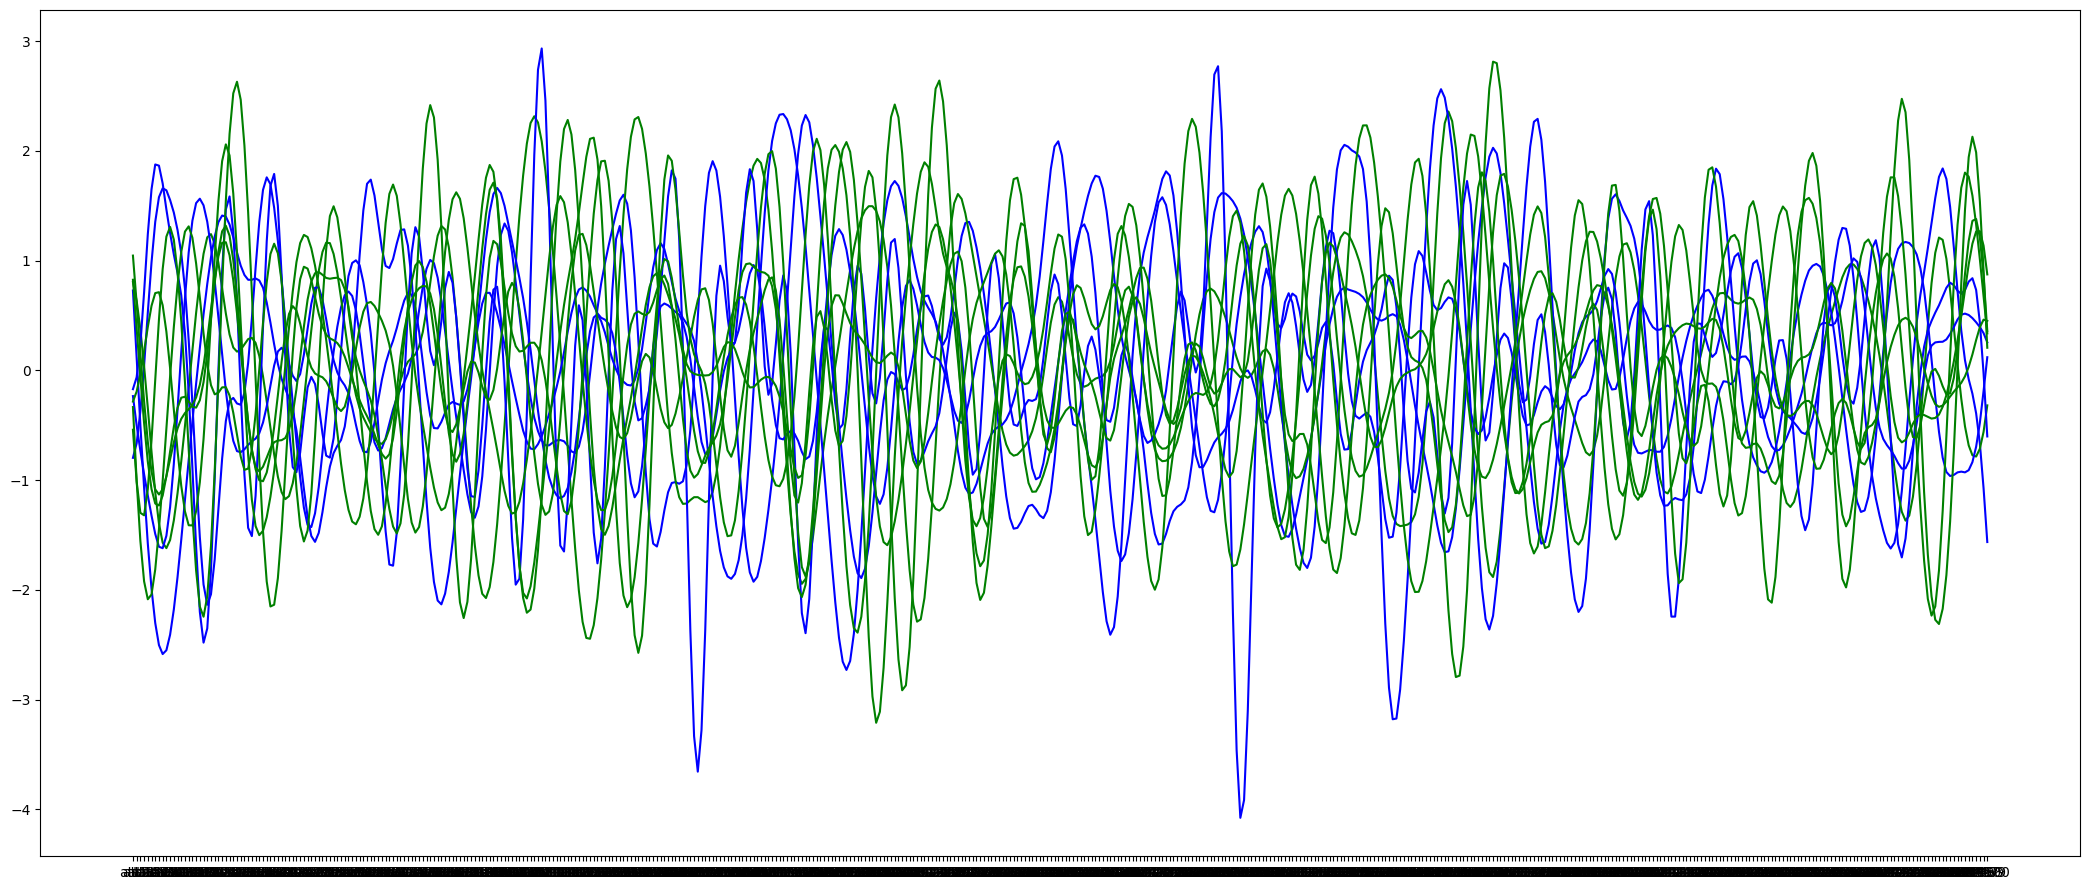

In [ ]:
colors = ['b', 'g']
plt.figure(figsize=(21,9))
for idx in range(10):
  plt.plot(train.iloc[idx][:-1], c=colors[int(train.iloc[idx, -1])])
plt.tight_layout()
plt.show()

In [ ]:
train.head()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att492,att493,att494,att495,att496,att497,att498,att499,att500,target
0,-0.797172,-0.664392,-0.373015,0.040815,0.526936,0.984288,1.353120,1.578108,1.659251,1.640809,...,0.722417,0.362068,0.092083,-0.081268,-0.212573,-0.391456,-0.664392,-1.073796,-1.564343,0
1,0.804855,0.634629,0.373474,0.038343,-0.340988,-0.740860,-1.109667,-1.395357,-1.570192,-1.619951,...,0.049213,-0.258138,-0.510583,-0.683647,-0.773817,-0.785255,-0.714885,-0.560443,-0.319086,1
2,0.727985,0.111284,-0.499124,-1.068629,-1.578351,-1.990534,-2.302031,-2.503403,-2.585211,-2.550600,...,0.463685,0.507735,0.517174,0.504588,0.476270,0.438513,0.394463,0.339400,0.255391,0
3,-0.234439,-0.502157,-0.732488,-0.946128,-1.139739,-1.323336,-1.490243,-1.607077,-1.620430,-1.506933,...,-0.929437,-0.922761,-0.929437,-0.909409,-0.835970,-0.695768,-0.478790,-0.188707,0.119736,0
4,-0.171328,-0.062285,0.235829,0.710396,1.239969,1.649823,1.876321,1.865535,1.703751,1.466467,...,0.725496,0.697453,0.731967,0.808545,0.839823,0.733046,0.437520,-0.026585,-0.602213,0


In [ ]:
train.groupby('target').mean()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att491,att492,att493,att494,att495,att496,att497,att498,att499,att500
target,,,,,,,,,,,,,,,,,,,,,
0,-0.014895,-0.015515,-0.016355,-0.016704,-0.015422,-0.011477,-0.006306,-0.001435,0.002810,0.004730,...,0.020576,0.014972,0.006110,-0.003215,-0.010949,-0.014388,-0.012541,-0.006267,0.002245,0.010434
1,-0.018616,-0.015013,-0.010712,-0.006936,-0.004227,-0.002419,-0.000538,0.002675,0.008029,0.015609,...,-0.003742,-0.001601,0.001889,0.005288,0.007573,0.008220,0.006549,0.002857,-0.002297,-0.008113


In [ ]:
train.groupby('target').std()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att491,att492,att493,att494,att495,att496,att497,att498,att499,att500
target,,,,,,,,,,,,,,,,,,,,,
0,1.046503,1.038535,1.030145,1.031180,1.041815,1.051984,1.053741,1.048960,1.042726,1.03680,...,1.037209,1.037731,1.034531,1.025603,1.011854,0.997298,0.987655,0.990511,1.007039,1.028501
1,1.071179,1.066081,1.059798,1.054695,1.052556,1.053998,1.057515,1.060192,1.058752,1.05203,...,1.038403,1.043903,1.047698,1.048433,1.045641,1.040933,1.036925,1.035120,1.035589,1.036879


([], [])

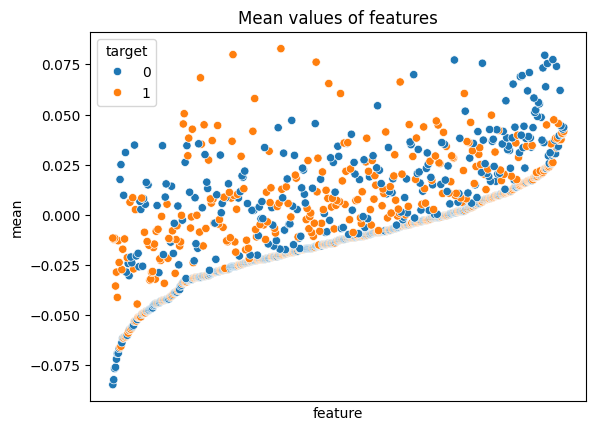

In [ ]:
train.groupby('target').mean().stack().reset_index(name='mean').rename(columns={'level_1':'feature'}).sort_values('mean')
sns.scatterplot(data=train.groupby('target').mean().stack().reset_index(name='mean').rename(columns={'level_1':'feature'}).sort_values('mean'), y='mean', x='feature', hue='target').set_title('Mean values of features')
plt.xticks([])

# Check the labels balance
* 🔎 Which metrics can we use? Why?

In [ ]:
train.target.value_counts()

,count
target,
0,1846
1,1755


# Convert the data into numpy arrays and separates *X* and *y* data from each other for training and testing data.

In [ ]:
train_x, train_y = train.drop(columns=['target']).values, train.target.values
test_x, test_y = test.drop(columns=['target']).values, test.target.values

## ⚡ Create a baseline model
* Lets try some simple basic model on the data. DecisionTree and RandomForrest.
    * As you will see it is a difficult task for them to get high accuracy results.

In [ ]:
base_models = [DecisionTreeClassifier(random_state=13), RandomForestClassifier(random_state=13)]

for model in base_models:
    model.fit(train_x, train_y)
    y_pred = model.predict(test_x)
    print(type(model).__name__)
    compute_metrics(test_y, y_pred)

DecisionTreeClassifier
	Accuracy:    56.36%
RandomForestClassifier
	Accuracy:    73.18%


## Fully connected ANN model
* Let's try some basic neural network model for this task.
    * It is a typical Dense network with two hidden layers and dropout optimization - it should be able to beat the Randomforrest classifier.

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=train_x[0].shape),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()
model.compile(optimizer=keras.optimizers.Adam(), loss = keras.losses.BinaryCrossentropy(from_logits=False), metrics = [keras.metrics.BinaryAccuracy()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       128,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,561 (822.50 KB)

 Trainable params: 210,561 (822.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - binary_accuracy: 0.6403 - loss: 0.6287 - val_binary_accuracy: 0.6644 - val_loss: 0.5943
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7410 - loss: 0.5282 - val_binary_accuracy: 0.6879 - val_loss: 0.5844
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7816 - loss: 0.4586 - val_binary_accuracy: 0.7101 - val_loss: 0.5695
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8267 - loss: 0.4007 - val_binary_accuracy: 0.7448 - val_loss: 0.5559
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8472 - loss: 0.3560 - val_binary_accuracy: 0.7503 - val_loss: 0.5328
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8740 - loss: 0.3156 - val_binary_accuracy: 0.7254 - val_loss: 0.5526
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8878 - loss: 0.2770 - val_binary_accuracy: 0.7420 - val_loss: 0.5672
Epoch 8/10
90/90 ━━

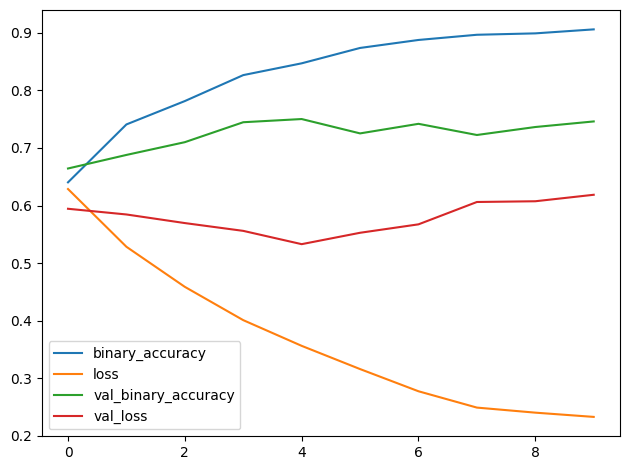

In [ ]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=10, batch_size=32, callbacks=[model_checkpoint_callback])
show_history(history)

model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x, test_y)
print('Test accuracy: ', test_acc)

# 🚀 Now we will finally use the CNN! 🙂
* To use convolution in single dimension we need to reshape the data to have the proper format.
    * The format is the same as for RNN and must be in a format $(number\_of\_vectors, vector\_length,number\_of\_dimensions)$
        * Given the user experience for the time series analysis tasks in Tensorflow, sharing the same input format between CNN and RNN must've been an accident 😅

In [ ]:
train_xc = np.reshape(train_x, (*train_x.shape, 1))
test_xc = np.reshape(test_x, (*test_x.shape, 1))
train_xc.shape, test_xc.shape

((50000, 32, 32, 3, 1), (10000, 32, 32, 3, 1))

## Let's try the single convolution layer as a input mapping
* It generates a huge number of weights for Dense layers after flattening

* The results are far from excelent
    * 🔎 Why?

In [ ]:
model = keras.Sequential([
    keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=train_xc[0].shape),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()
model.compile(optimizer=keras.optimizers.Adam(), loss = keras.losses.BinaryCrossentropy(from_logits=False), metrics = [keras.metrics.BinaryAccuracy()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 498, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 31872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │     2,039,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,040,193 (7.78 MB)

 Trainable params: 2,040,193 (7.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - binary_accuracy: 0.5743 - loss: 0.6947 - val_binary_accuracy: 0.6325 - val_loss: 0.6471
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6837 - loss: 0.5922 - val_binary_accuracy: 0.6560 - val_loss: 0.6157
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7434 - loss: 0.5292 - val_binary_accuracy: 0.6616 - val_loss: 0.6000
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7740 - loss: 0.4799 - val_binary_accuracy: 0.6699 - val_loss: 0.6259
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.7885 - loss: 0.4499 - val_binary_accuracy: 0.6893 - val_loss: 0.6447
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.8181 - loss: 0.4196 - val_binary_accuracy: 0.6907 - val_loss: 0.6294
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.8361 - loss: 0.3758 - val_binary_accuracy: 0.6963 - val_loss: 0.6234
Epoch 8/10
90/90 ━━

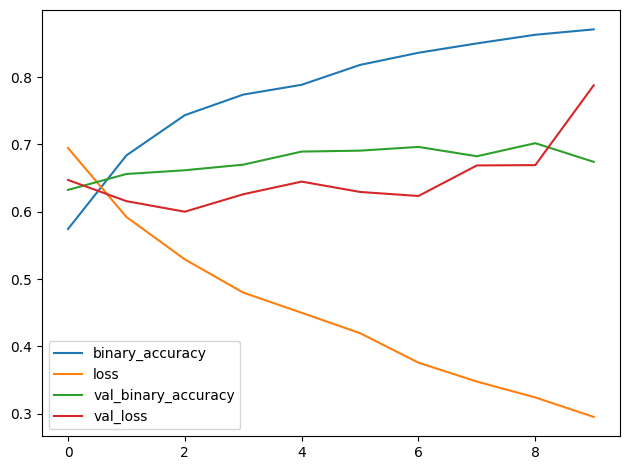

In [ ]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=10, batch_size=32, callbacks=[model_checkpoint_callback])
show_history(history)

model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x, test_y)
print('Test accuracy: ', test_acc)

## A slightly more complicated model is able to beat all previous models with smaller number of weights needed

In [ ]:
model = keras.Sequential([
    keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=train_xc[0].shape),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.MaxPool1D(2),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()
model.compile(optimizer=keras.optimizers.Adam(), loss = keras.losses.BinaryCrossentropy(from_logits=False), metrics = [keras.metrics.BinaryAccuracy()])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 498, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 496, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 248, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 246, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 244, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 15616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │       999,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,036,865 (3.96 MB)

 Trainable params: 1,036,865 (3.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - binary_accuracy: 0.5351 - loss: 0.6900 - val_binary_accuracy: 0.5257 - val_loss: 0.6736
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.6760 - loss: 0.5507 - val_binary_accuracy: 0.7989 - val_loss: 0.4518
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.8115 - loss: 0.3794 - val_binary_accuracy: 0.8391 - val_loss: 0.3457
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.8715 - loss: 0.2772 - val_binary_accuracy: 0.8641 - val_loss: 0.2863
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9219 - loss: 0.1842 - val_binary_accuracy: 0.8613 - val_loss: 0.3134
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9528 - loss: 0.1242 - val_binary_accuracy: 0.8710 - val_loss: 0.2969
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.9569 - loss: 0.1115 - val_binary_accuracy: 0.8599 - val_loss: 0.3316
Epoch 8/10
90/90 ━━

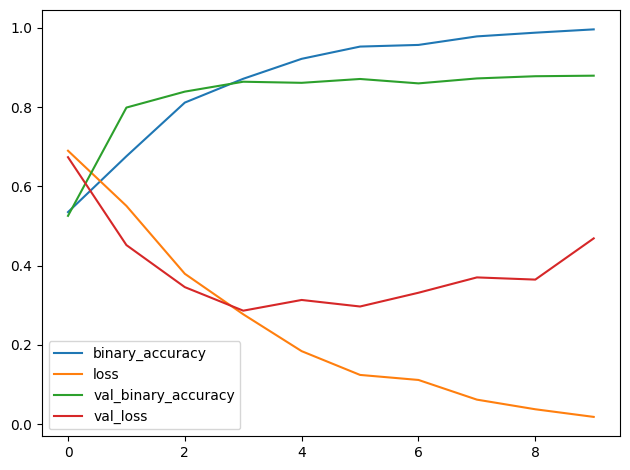

In [ ]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=10, batch_size=32, callbacks=[model_checkpoint_callback])
show_history(history)

model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x, test_y)
print('Test accuracy: ', test_acc)

## Even more capable model with more pooling layers but with 1/4 weight of the previsou model is able to achieve more than 90% of the accuracy

In [ ]:
model = keras.Sequential([
    keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=train_xc[0].shape),
    keras.layers.MaxPool1D(2),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.MaxPool1D(2),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.MaxPool1D(2),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()
model.compile(optimizer=keras.optimizers.Adam(), loss = keras.losses.BinaryCrossentropy(from_logits=False), metrics = [keras.metrics.BinaryAccuracy()])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 498, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 249, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 247, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 121, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 58, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3712)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │       237,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,009 (1.05 MB)

 Trainable params: 275,009 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - binary_accuracy: 0.5083 - loss: 0.6927 - val_binary_accuracy: 0.5257 - val_loss: 0.6668
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.6774 - loss: 0.5250 - val_binary_accuracy: 0.6644 - val_loss: 0.5054
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8104 - loss: 0.3909 - val_binary_accuracy: 0.8793 - val_loss: 0.3016
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8868 - loss: 0.2666 - val_binary_accuracy: 0.8835 - val_loss: 0.2572
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.9090 - loss: 0.2159 - val_binary_accuracy: 0.9126 - val_loss: 0.2302
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9378 - loss: 0.1653 - val_binary_accuracy: 0.9168 - val_loss: 0.2529
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9410 - loss: 0.1514 - val_binary_accuracy: 0.8571 - val_loss: 0.3572
Epoch 8/10
90/90 ━━

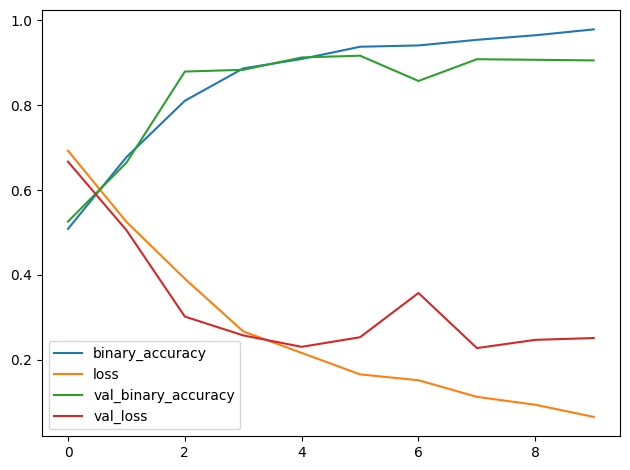

In [ ]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=10, batch_size=32, callbacks=[model_checkpoint_callback])
show_history(history)

model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x, test_y)
print('Test accuracy: ', test_acc)

# ✅  Tasks for the lecture (2p)

1) Choose any of the models from [Keras pre-trained models](https://keras.io/api/applications/) - **(1p)**

    * Investigate its' architecture
    * Search for the needed input shape for the model - remeber to preprocess the data and call correct `preprocess_input` function
        * 💡 There could be more variants of the model, the choice depends on you
    * Use the selected model for CIFAR-10 classification,
        * Fine-tune it, experiment with it and write down your conclusions!
    
2) Define your own model for the FordA data task  - **(1p)**

    * Try to beat defined models or have at least the same accuracy score
        * 💡 You can also try to minimize the number of parameters for having approx. the same accuracy as we do!
    * Experiment with the model and write down your conclusions!

Struktura malých filtrů: VGG-19 používá výhradně konvoluční filtry o velikosti 3x3. Toto zjednodušení umožňuje skládat vrstvy hlouběji za sebe, což síti pomáhá učit se komplexnější a abstraktnější nelineární vztahy v obraze.

Obrovská kapacita: Kompletní model obsahuje zhruba 143 milionů parametrů. To mu dává obrovskou sílu pro rozpoznávání vzorů (díky tréninku na obřím datasetu ImageNet), ale zároveň to vyžaduje opatrnost při trénování na menších datasetech kvůli vysokému riziku overfittingu (přeučení).

Vstupní rozlišení: Síť nativně očekává vstupní obrázky o velikosti 224x224 pixelů. Při aplikaci na dataset jako CIFAR-10 (obrázky 32x32) je proto nutné provést upscaling dat.

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

img_size_vgg19 = 224

print(f"VGG19 image size set to: {img_size_vgg19}x{img_size_vgg19}")
print("VGG19 model and preprocess_input function imported.")

VGG19 image size set to: 224x224
VGG19 model and preprocess_input function imported.


In [ ]:
base_model_vgg19 = VGG19(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(img_size_vgg19, img_size_vgg19, 3),
    include_top=False)  # Do not include the ImageNet classifier part at the top.

print("VGG19 model instantiated.")
base_model_vgg19.summary()

VGG19 model instantiated.


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
base_model_vgg19.trainable = False
print("VGG19 base model layers frozen.")

VGG19 base model layers frozen.


In [ ]:
inputs = keras.Input(shape=(img_size_vgg19, img_size_vgg19, 3), dtype=tf.uint8)
x = keras.ops.cast(inputs, dtype=tf.float32)
x = preprocess_input(x)
x = base_model_vgg19(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(class_count, activation='softmax')(x)
model_vgg19 = keras.Model(inputs, outputs)

model_vgg19.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ cast[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ cast[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 7, 7, 512) │ 20,024,384 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg19[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │      5,130 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,029,514 (76.41 MB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
model_vgg19.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy()])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ cast[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ cast[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 7, 7, 512) │ 20,024,384 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg19[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │      5,130 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,029,514 (76.41 MB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
train_x_resized_vgg19 = tf.image.resize(train_x[:subset], [img_size_vgg19, img_size_vgg19])
test_x_resized_vgg19 = tf.image.resize(test_x[:subset], [img_size_vgg19, img_size_vgg19])

print(f"Resized training data shape: {train_x_resized_vgg19.shape}, training labels shape: {train_y.shape}")
print(f"Resized test data shape: {test_x_resized_vgg19.shape}, test labels shape: {test_y.shape}")

Resized training data shape: (1000, 224, 224, 3), training labels shape: (1000, 10)
Resized test data shape: (1000, 224, 224, 3), test labels shape: (1000, 10)


In [ ]:
model_checkpoint_callback_vgg19 = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_vgg19_frozen.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

ModelCheckpoint callback for VGG19 (frozen layers) created.


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 604ms/step - categorical_accuracy: 0.2113 - loss: 3.1328 - val_categorical_accuracy: 0.3400 - val_loss: 2.3236
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 341ms/step - categorical_accuracy: 0.4512 - loss: 1.7470 - val_categorical_accuracy: 0.4550 - val_loss: 1.7074
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 344ms/step - categorical_accuracy: 0.5813 - loss: 1.2428 - val_categorical_accuracy: 0.5200 - val_loss: 1.4449
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 332ms/step - categorical_accuracy: 0.6800 - loss: 0.9410 - val_categorical_accuracy: 0.6050 - val_loss: 1.2265
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 318ms/step - categorical_accuracy: 0.7212 - loss: 0.7702 - val_categorical_accuracy: 0.5950 - val_loss: 1.1328
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 310ms/step - categorical_accuracy: 0.7825 - loss: 0.6343 - val_categorical_accuracy: 0.6300 - val_loss: 1.0395
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 305ms/step - categorical_accuracy: 0.8213 - lo

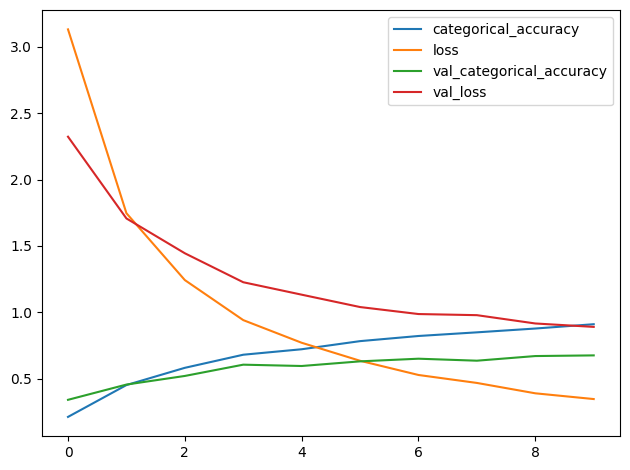

In [ ]:
history_vgg19_frozen = model_vgg19.fit(train_x_resized_vgg19, train_y, validation_split=0.2, batch_size=32, epochs=10, callbacks=[model_checkpoint_callback_vgg19])

show_history(history_vgg19_frozen)

# Load best setup
model_vgg19.load_weights("best_vgg19_frozen.weights.h5")
test_loss_vgg19_frozen, test_acc_vgg19_frozen = model_vgg19.evaluate(test_x_resized_vgg19, test_y)
print(f'VGG19 (Frozen Layers) Test accuracy: {test_acc_vgg19_frozen*100:8.2f}%')

In [ ]:
base_model_vgg19.trainable = True
print("VGG19 base model layers unfrozen for fine-tuning.")

VGG19 base model layers unfrozen for fine-tuning.


In [ ]:
model_vgg19.compile(optimizer=keras.optimizers.Adam(1e-5), # Use a very low learning rate
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy()])

model_vgg19.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ cast[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ cast[0][0]        │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 7, 7, 512) │ 20,024,384 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg19[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │      5,130 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,029,514 (76.41 MB)

 Trainable params: 20,029,514 (76.41 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_checkpoint_callback_vgg19_fine_tune = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_vgg19_fine_tune.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

print("ModelCheckpoint callback for VGG19 (fine-tuning) created.")

ModelCheckpoint callback for VGG19 (fine-tuning) created.


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 78s 820ms/step - categorical_accuracy: 0.8800 - loss: 0.3707 - val_categorical_accuracy: 0.6950 - val_loss: 0.9302
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 748ms/step - categorical_accuracy: 0.9550 - loss: 0.1409 - val_categorical_accuracy: 0.7050 - val_loss: 0.8364
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 765ms/step - categorical_accuracy: 0.9937 - loss: 0.0350 - val_categorical_accuracy: 0.7450 - val_loss: 0.9145
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 764ms/step - categorical_accuracy: 1.0000 - loss: 0.0096 - val_categorical_accuracy: 0.7400 - val_loss: 0.9611
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 744ms/step - categorical_accuracy: 1.0000 - loss: 0.0039 - val_categorical_accuracy: 0.7500 - val_loss: 0.9690
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 738ms/step - categorical_accuracy: 1.0000 - loss: 0.0020 - val_categorical_accuracy: 0.7450 - val_loss: 0.9955
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 755ms/step - categorical_accuracy: 1.000

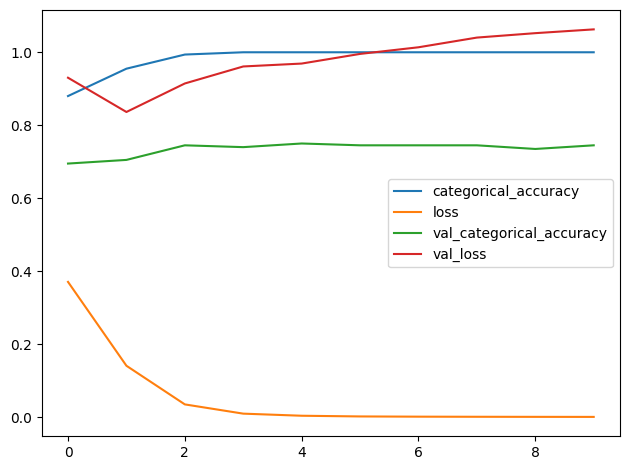

In [ ]:
history_vgg19_fine_tune = model_vgg19.fit(train_x_resized_vgg19, train_y, validation_split=0.2, batch_size=32, epochs=10, callbacks=[model_checkpoint_callback_vgg19_fine_tune])

show_history(history_vgg19_fine_tune)

# Load best setup after fine-tuning
model_vgg19.load_weights("best_vgg19_fine_tune.weights.h5")
test_loss_vgg19_fine_tune, test_acc_vgg19_fine_tune = model_vgg19.evaluate(test_x_resized_vgg19, test_y)
print(f'VGG19 (Fine-tuned Layers) Test accuracy: {test_acc_vgg19_fine_tune*100:8.2f}%')

VGG-19 model je zbytečně moc velký a došlo k overfittingu

## Design Custom Model for FordA Data



Vstupní vrstva: Očekává data ve formátu časových řad o délce 500 kroků s jednou proměnnou – tedy tvar (500, 1).

První konvoluční blok (Extrakce základních rysů):

* Conv1D: 32 filtrů s velikostí jádra (kernel size) 5 a aktivační funkcí ReLU.
Zde model hledá širší a základní vzory v signálu.

* MaxPool1D: S velikostí okna 2 zmenšuje délku řady na polovinu a vybírá z ní ty nejvýraznější rysy.

Druhý konvoluční blok (Střední úroveň detailů):

* Conv1D: Počet filtrů se zvyšuje na 64, velikost jádra je 3 (ReLU).

* MaxPool1D: Opět zmenšuje dimenzi na polovinu.

Třetí konvoluční blok (Hluboké a abstraktní rysy):

* Conv1D: Počet filtrů se zdvojnásobuje na 128, velikost jádra je 3 (ReLU).

* MaxPool1D: Poslední redukce velikosti pomocí poolingu.

Klasifikační hlava (Rozhodovací část):

* Flatten: Zploští vícerozměrné mapy příznaků z předchozích vrstev do jednoho dlouhého 1D vektoru, aby je bylo možné předat do plně propojených vrstev.

* Dense: Plně propojená vrstva se 128 neurony (ReLU).

* Dropout (0.3): Klíčová regularizační technika, která náhodně "vypne" 30 % neuronů během tréninku. To efektivně brání přeučení sítě (overfittingu).

* Dense: Další skrytá vrstva se 64 neurony (ReLU).

Výstupní Dense: 1 neuron s aktivační funkcí sigmoid. Jelikož jde o binární klasifikaci (určujeme, zda symptom existuje, či neexistuje), výstupem je pravděpodobnost od 0 do 1.

In [ ]:
train = pd.read_feather('https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets/FordA_TRAIN.feather')
test = pd.read_feather('https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets/FordA_TEST.feather')
train["target"] = train["target"].replace(-1, 0)
test["target"] = test["target"].replace(-1, 0)

train_x, train_y = train.drop(columns=['target']).values, train.target.values
test_x, test_y = test.drop(columns=['target']).values, test.target.values

train_xc = np.reshape(train_x, (train_x.shape[0], train_x.shape[1], 1))
test_xc = np.reshape(test_x, (test_x.shape[0], test_x.shape[1], 1))

print(f"Corrected train_xc shape for FordA: {train_xc.shape}")
print(f"Corrected test_xc shape for FordA: {test_xc.shape}")

model_forda_custom = keras.Sequential([
    keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=train_xc.shape[1:]),
    keras.layers.MaxPool1D(pool_size=2),
    keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    keras.layers.MaxPool1D(pool_size=2),
    keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
    keras.layers.MaxPool1D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dense(units=1, activation='sigmoid')
])

model_forda_custom.summary()

Corrected train_xc shape for FordA: (3601, 500, 1)
Corrected test_xc shape for FordA: (1320, 500, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 496, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 248, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 246, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 121, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       983,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,022,593 (3.90 MB)

 Trainable params: 1,022,593 (3.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train = pd.read_feather('https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets/FordA_TRAIN.feather')
test = pd.read_feather('https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets/FordA_TEST.feather')
train["target"] = train["target"].replace(-1, 0)
test["target"] = test["target"].replace(-1, 0)

train_x, train_y = train.drop(columns=['target']).values, train.target.values
test_x, test_y = test.drop(columns=['target']).values, test.target.values

train_xc = np.reshape(train_x, (train_x.shape[0], train_x.shape[1], 1))
test_xc = np.reshape(test_x, (test_x.shape[0], test_x.shape[1], 1))

print(f"Corrected train_xc shape for FordA: {train_xc.shape}")
print(f"Corrected test_xc shape for FordA: {test_xc.shape}")

model_forda_custom = keras.Sequential([
    keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=train_xc.shape[1:]),
    keras.layers.MaxPool1D(pool_size=2),
    keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    keras.layers.MaxPool1D(pool_size=2),
    keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
    keras.layers.MaxPool1D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dense(units=1, activation='sigmoid')
])

model_forda_custom.compile(optimizer=keras.optimizers.Adam(),
                           loss=keras.losses.BinaryCrossentropy(from_logits=False),
                           metrics=[keras.metrics.BinaryAccuracy()])

model_forda_custom.summary()

Corrected train_xc shape for FordA: (3601, 500, 1)
Corrected test_xc shape for FordA: (1320, 500, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 496, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 248, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 246, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 121, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │       983,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,022,593 (3.90 MB)

 Trainable params: 1,022,593 (3.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_checkpoint_callback_forda_custom = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_forda_custom.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

print("ModelCheckpoint callback for custom FordA model created.")

ModelCheckpoint callback for custom FordA model created.


Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - binary_accuracy: 0.6163 - loss: 0.6099 - val_binary_accuracy: 0.7032 - val_loss: 0.5358
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8083 - loss: 0.3687 - val_binary_accuracy: 0.9057 - val_loss: 0.2746
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8806 - loss: 0.2798 - val_binary_accuracy: 0.8988 - val_loss: 0.2888
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9087 - loss: 0.2260 - val_binary_accuracy: 0.8918 - val_loss: 0.2860
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9108 - loss: 0.2121 - val_binary_accuracy: 0.8849 - val_loss: 0.2477
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9340 - loss: 0.1682 - val_binary_accuracy: 0.9140 - val_loss: 0.2713
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9399 - loss: 0.1537 - val_binary_accuracy: 0.9168 - val_loss: 0.2295
Epoch 8/10
90/90 ━━

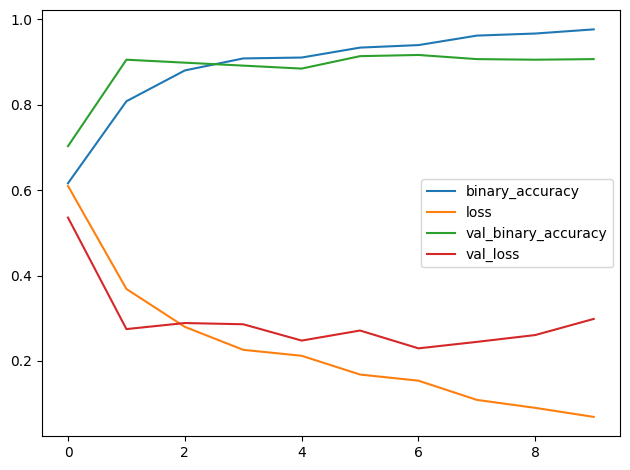

In [ ]:
history_forda_custom = model_forda_custom.fit(train_xc, train_y, validation_split=0.2, epochs=10, batch_size=32, callbacks=[model_checkpoint_callback_forda_custom])
show_history(history_forda_custom)

# Load best setup
model_forda_custom.load_weights("best_forda_custom.weights.h5")
test_loss_forda_custom, test_acc_forda_custom = model_forda_custom.evaluate(test_xc, test_y)
print(f'Custom FordA Model Test accuracy: {test_acc_forda_custom*100:8.2f}%')